In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/home/davian/Projects/ML-Template/clasificacion/data/breast-cancer.csv')

In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [3]:
from preprocessing.split_data import dividir_datos
from src.config import TARGET

x_train, x_test, y_train, y_test = dividir_datos(df, target=TARGET)

In [4]:
from preprocessing.pipeline import estandarizar, codificar

x_train_prep, x_test_prep, _ = estandarizar(x_train, x_test)

y_train_prep, y_test_prep, _ = codificar(y_train, y_test)

### Busqueda del modelo

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


models = {
    'lr_model': LogisticRegression(),
    'tree': DecisionTreeClassifier(),
    'rf_model': RandomForestClassifier(),
    'svc': SVC(),
    'naive bayes': GaussianNB(),
}

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

resultado =  []

for name, model in models.items():
    model.fit(x_train_prep, y_train_prep)

    y_pred = model.predict(x_test_prep)

    acccuracy = accuracy_score(y_test_prep, y_pred)
    precision = precision_score(y_test_prep, y_pred)
    recall = recall_score(y_test_prep, y_pred)
    f1 = f1_score(y_test_prep, y_pred)

    resultado.append({'model': name, 'acurracy': acccuracy, 'precision': precision, 'recall': recall, 'f1_score': f1})

In [15]:
metricas_df = pd.DataFrame(resultado)
metricas_df

,model,acurracy,precision,recall,f1_score
0,lr_model,0.964912,0.975000,0.928571,0.951220
1,tree,0.929825,0.947368,0.857143,0.900000
2,rf_model,0.973684,1.000000,0.928571,0.962963
3,svc,0.964912,0.975000,0.928571,0.951220
4,naive bayes,0.921053,0.923077,0.857143,0.888889


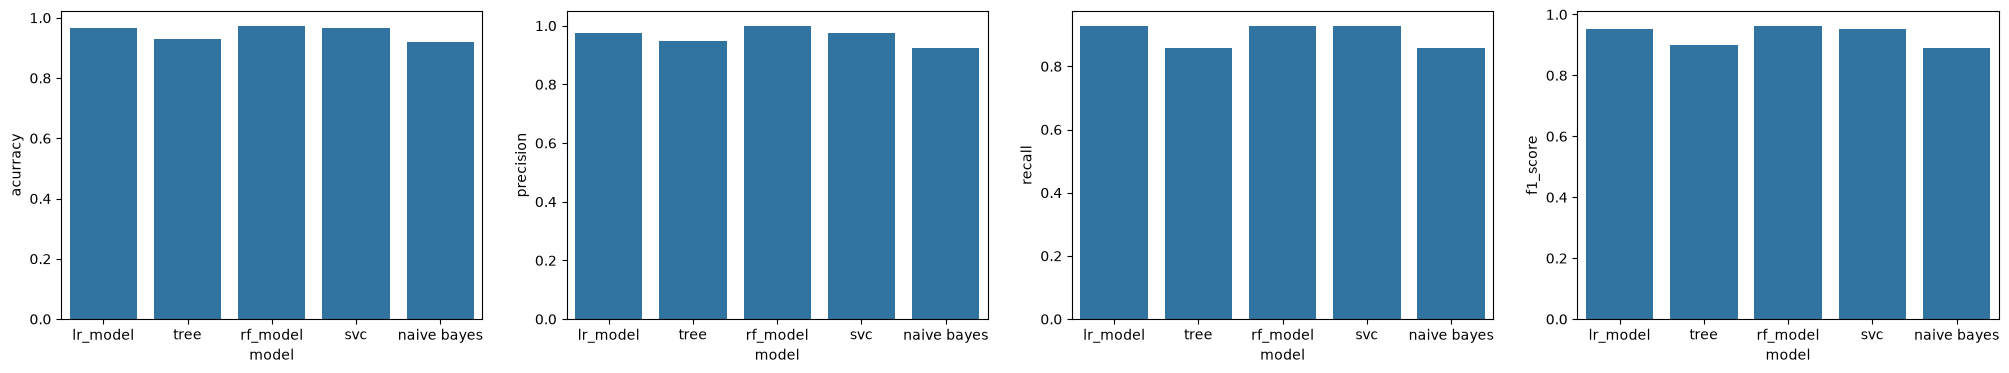

In [16]:
metrics = ['acurracy', 'precision', 'recall','f1_score']

plt.figure(figsize=(25, 4))
for i, metric in enumerate(metrics, start=1):
    plt.subplot(1, 4, i)
    sns.barplot(data=metricas_df, x='model', y=metric)


### Busqueda de hiperparametros

In [17]:
hiperparametros = {
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],  
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'], 
    'max_iter': [100, 200, 300, 400, 500, 1000, 2000],         
    'tol': [1e-4, 1e-3, 1e-2, 1e-1],                
    'class_weight': [None, 'balanced']              
}

In [28]:
from sklearn.model_selection import GridSearchCV

lr_model = GridSearchCV(estimator=LogisticRegression(), param_grid=hiperparametros, cv=5)

lr_model.fit(x_train_prep, y_train_prep)

/home/davian/Projects/ML-Template/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/davian/Projects/ML-Template/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/da

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'max_iter': [100, 200, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...], ...}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True


In [29]:
lr_model.best_params_

{'class_weight': None,
 'max_iter': 400,
 'penalty': 'l1',
 'solver': 'saga',
 'tol': 0.1}

## 4.- Evaluacion

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [32]:
y_pred = lr_model.predict(x_test_prep)

print(
    'acurracy: ', accuracy_score(y_test_prep, y_pred),
    '\nprecision: ', precision_score(y_test_prep, y_pred),
    '\nrecall: ', recall_score(y_test_prep, y_pred),
    '\nf1 score', f1_score(y_test_prep, y_pred) 
)

acurracy:  0.9824561403508771 
precision:  1.0 
recall:  0.9523809523809523 
f1 score 0.975609756097561


Text(50.83333333333332, 0.5, 'Real')

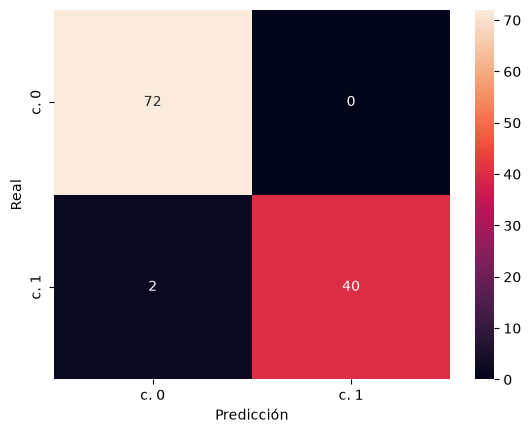

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_prep, y_pred)

sns.heatmap(cm, annot=True, xticklabels=['c. 0', 'c. 1',], yticklabels=['c. 0', 'c. 1'])
plt.xlabel("Predicción")
plt.ylabel("Real")